# Step 2 - Build Digital Tech Corpus

                This notebook constructs the digital-tech core corpus, keeps a broader tech-company
                slice for robustness, and saves manual audit samples for scope review.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from linkedin_experiment.pipeline import build_scope_outputs

outputs = build_scope_outputs()
outputs


d:\Files\UCLA\CLASSES\4th yr\Winter 2026\COMM 129\Project\encoded-inequality\src\linkedin_experiment\scope.py:165: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["is_tech_industry"] = merged["is_tech_industry"].fillna(False)


{'scope_all': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_scope_all.csv'),
 'core': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_digital_tech_core.csv'),
 'broad': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_broad_tech_company.csv'),
 'summary': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/scope/scope_summary.csv'),
 'included_sample': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/scope/included_title_audit_sample.csv'),
 'excluded_sample': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/scope/excluded_title_audit_sample.csv')}

In [2]:
scope_summary = pd.read_csv("../results/scope/scope_summary.csv")
included_sample = pd.read_csv("../results/scope/included_title_audit_sample.csv")
excluded_sample = pd.read_csv("../results/scope/excluded_title_audit_sample.csv")
scope_summary, included_sample.head(10), excluded_sample.head(10)


(                    metric   value
 0               rows_total  123849
 1            rows_in_scope   10511
 2        rows_out_of_scope  113338
 3  broad_tech_company_rows   20411,
        job_id                                     title  \
 0  3891073928                         Software Engineer   
 1  3899538732                              Data Analyst   
 2  3901394243                            Technical Lead   
 3  3900084008                             ETL Developer   
 4  3890896146                             iOS Developer   
 5  3854900554                           Head of Product   
 6  3901478018  Senior Full Stack Developer (Blockchain)   
 7  3840166122               Senior Salesforce Developer   
 8  3901347421               Software Engineer (Backend)   
 9  3885806687                             Data Engineer   
 
                 company_name formatted_experience_level  \
 0                     Sonobi                        NaN   
 1              Russell Tobin        

In [3]:
core = pd.read_csv("../data/processed/linkedin_digital_tech_core.csv")
core[["job_id", "title", "scope_reason", "industry_name"]].head(20)


,job_id,title,scope_reason,industry_name
0,133130219,Software Engineer,title_core,IT Services and IT Consulting
1,175485704,Software Engineer,title_core,"Technology, Information and Internet"
2,2234533717,Full Stack Engineer,title_core,Business Consulting and Services
3,2269442456,Computer Scientist,title_core,Space Research and Technology
4,3075721793,Architect/Project Manager,ambiguous_title_supported,Architecture and Planning
5,3169712432,Salesforce Vlocity Developer,title_core,IT Services and IT Consulting
6,3245063922,Data Architect,title_core,IT Services and IT Consulting
7,3366698309,Anaplan Developer,title_core,IT Services and IT Consulting
8,3398076960,Technical Product and IT Manager for Data Cent...,title_leadership,NaN
9,3475933396,Senior Developer,title_core,Insurance


## Report Visual Aids

These plots use the saved scope outputs only, so you can generate report figures without rebuilding the corpus.


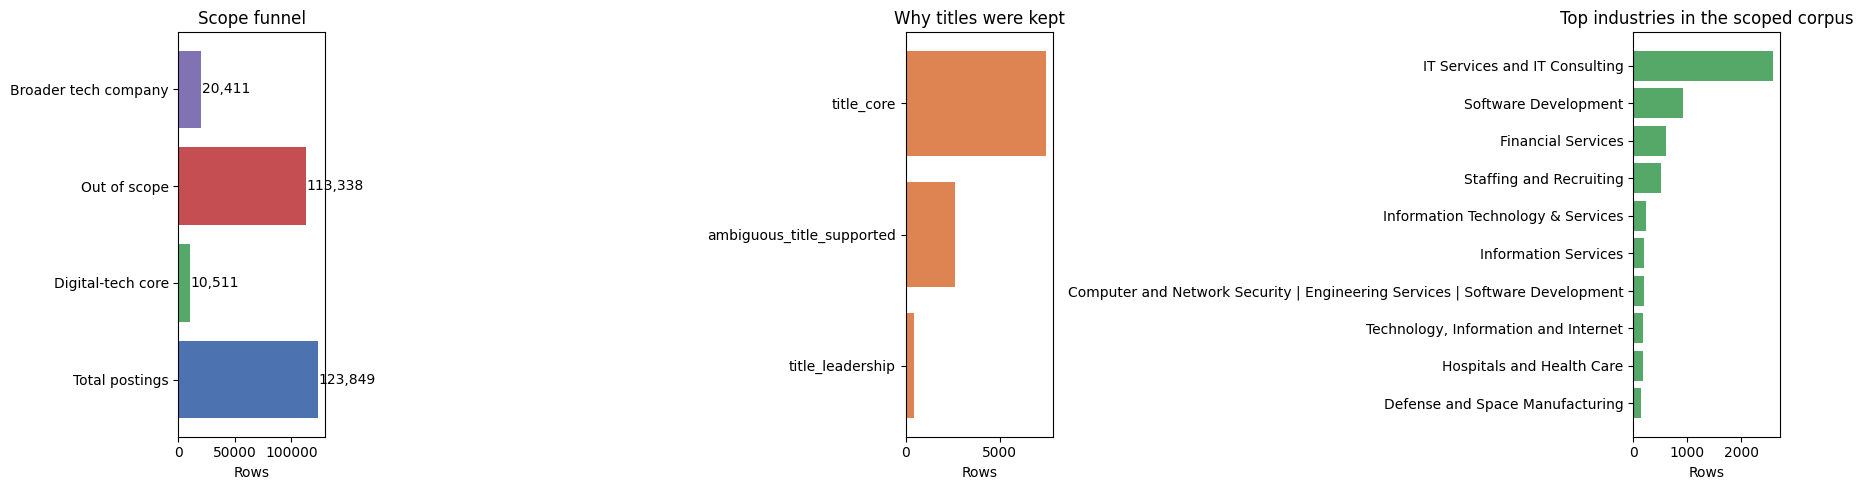

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

scope_dir = Path("../results/scope")
processed_dir = Path("../data/processed")

scope_summary = pd.read_csv(scope_dir / "scope_summary.csv")
core = pd.read_csv(
    processed_dir / "linkedin_digital_tech_core.csv",
    usecols=["scope_reason", "industry_name"],
)

summary_map = scope_summary.set_index("metric")["value"]
funnel = pd.Series(
    {
        "Total postings": summary_map["rows_total"],
        "Digital-tech core": summary_map["rows_in_scope"],
        "Out of scope": summary_map["rows_out_of_scope"],
        "Broader tech company": summary_map["broad_tech_company_rows"],
    }
)
scope_reasons = core["scope_reason"].fillna("Missing").value_counts().sort_values()
top_industries = core["industry_name"].fillna("Missing").value_counts().head(10).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(funnel.index, funnel.values, color=["#4c72b0", "#55a868", "#c44e52", "#8172b3"])
axes[0].set_title("Scope funnel")
axes[0].set_xlabel("Rows")
for idx, value in enumerate(funnel.values):
    axes[0].text(value + 300, idx, f"{int(value):,}", va="center")

axes[1].barh(scope_reasons.index, scope_reasons.values, color="#dd8452")
axes[1].set_title("Why titles were kept")
axes[1].set_xlabel("Rows")

axes[2].barh(top_industries.index, top_industries.values, color="#55a868")
axes[2].set_title("Top industries in the scoped corpus")
axes[2].set_xlabel("Rows")

plt.tight_layout()

plot_name = "Step 2 - Report Visual Aids"
plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches="tight")

plt.show()
